In [7]:
%pip install scipy
%pip install matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.
  Using cached matplotlib-3.10.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-ma

In [14]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import math
import warnings
warnings.filterwarnings('ignore')

In [31]:


# Load the dataset
data = pd.read_csv('/home/ciline/Téléchargements/ship_fuel_efficiency.csv')


In [35]:

# Basic Probability: Picking a 'Stormy' trip
all_trips = data.shape[0]
stormy_trips = data[data['weather_conditions'] == 'Stormy'].shape[0]
prob_stormy = (stormy_trips / all_trips) * 100

# Conditional Probability: Two Stormy trips in a row
cond_prob = (stormy_trips/all_trips) * ((stormy_trips - 1)/(all_trips - 1))

print(f"Total Trips in Dataset: {all_trips}")
print(f"Probability of a trip being 'Stormy': {prob_stormy:.2f}%")
print(f"Probability of two consecutive Stormy trips: {cond_prob*100:.4f}%")

Total Trips in Dataset: 1440
Probability of a trip being 'Stormy': 32.08%
Probability of two consecutive Stormy trips: 10.2783%


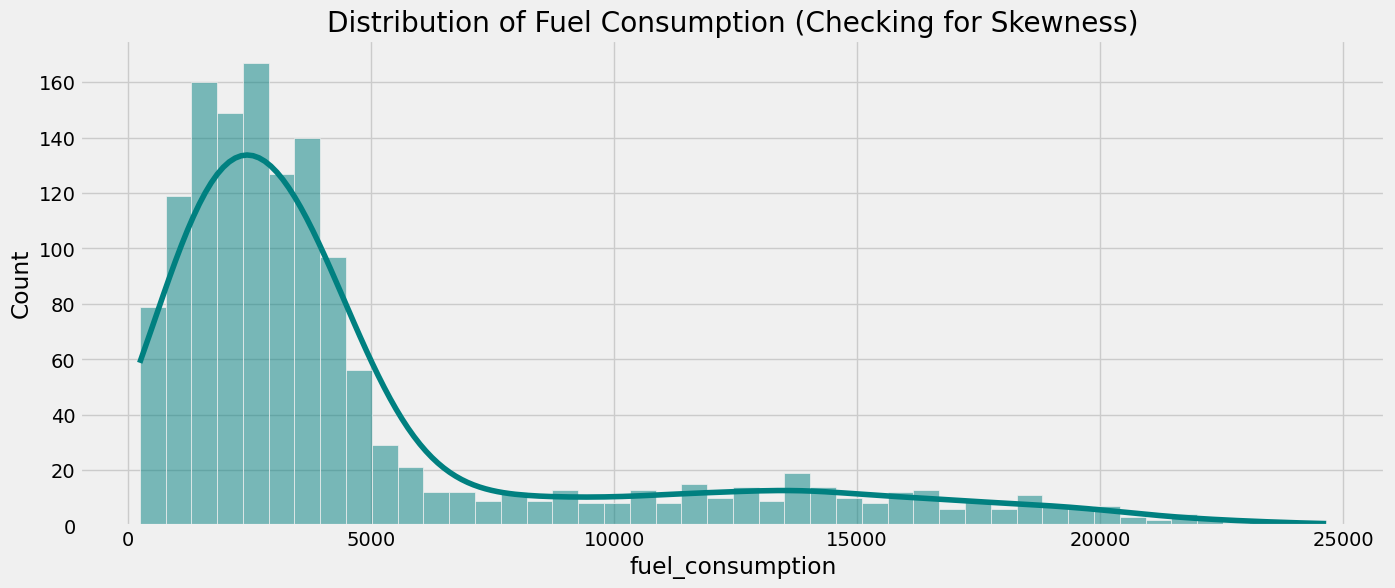

Mean Fuel: 4844.25
Standard Deviation: 4892.35
Z-score for the first trip: -0.22


In [36]:
# Checking for Skewness in Fuel Consumption
sns.histplot(data['fuel_consumption'], kde=True, color='teal')
plt.title('Distribution of Fuel Consumption (Checking for Skewness)')
plt.show()

# Z-Score calculation for a specific trip
mean_fuel = data['fuel_consumption'].mean()
std_fuel = data['fuel_consumption'].std()
specific_trip_fuel = data['fuel_consumption'].iloc[0]
z_score = (specific_trip_fuel - mean_fuel) / std_fuel

print(f"Mean Fuel: {mean_fuel:.2f}")
print(f"Standard Deviation: {std_fuel:.2f}")
print(f"Z-score for the first trip: {z_score:.2f}")

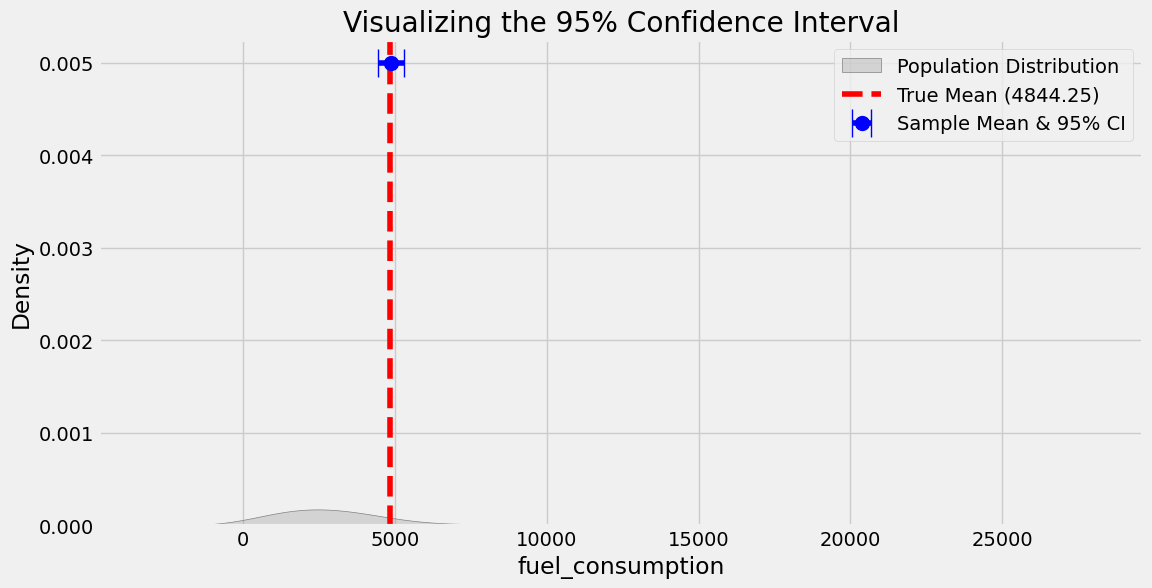

95% Confidence interval: (np.float64(4430.75560833447), np.float64(5288.4071116655305))


In [37]:
np.random.seed(10)
sample_size = 500
sample = np.random.choice(a=data['fuel_consumption'], size=sample_size)
sample_mean = sample.mean()

# 95% Confidence Interval Calculation
z_critical = stats.norm.ppf(q = 0.975) 
margin_of_error = z_critical * (std_fuel / math.sqrt(sample_size))
confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)

# Visualization
plt.figure(figsize=(12, 6))
sns.kdeplot(data['fuel_consumption'], fill=True, color="gray", label="Population Distribution")
plt.axvline(mean_fuel, color='red', linestyle='--', label=f'True Mean ({mean_fuel:.2f})')
plt.errorbar(x=sample_mean, y=0.005, xerr=margin_of_error, fmt='o', 
             color='blue', markersize=10, capsize=10, label='Sample Mean & 95% CI')

plt.title("Visualizing the 95% Confidence Interval")
plt.legend()
plt.show()

print(f"95% Confidence interval: {confidence_interval}")

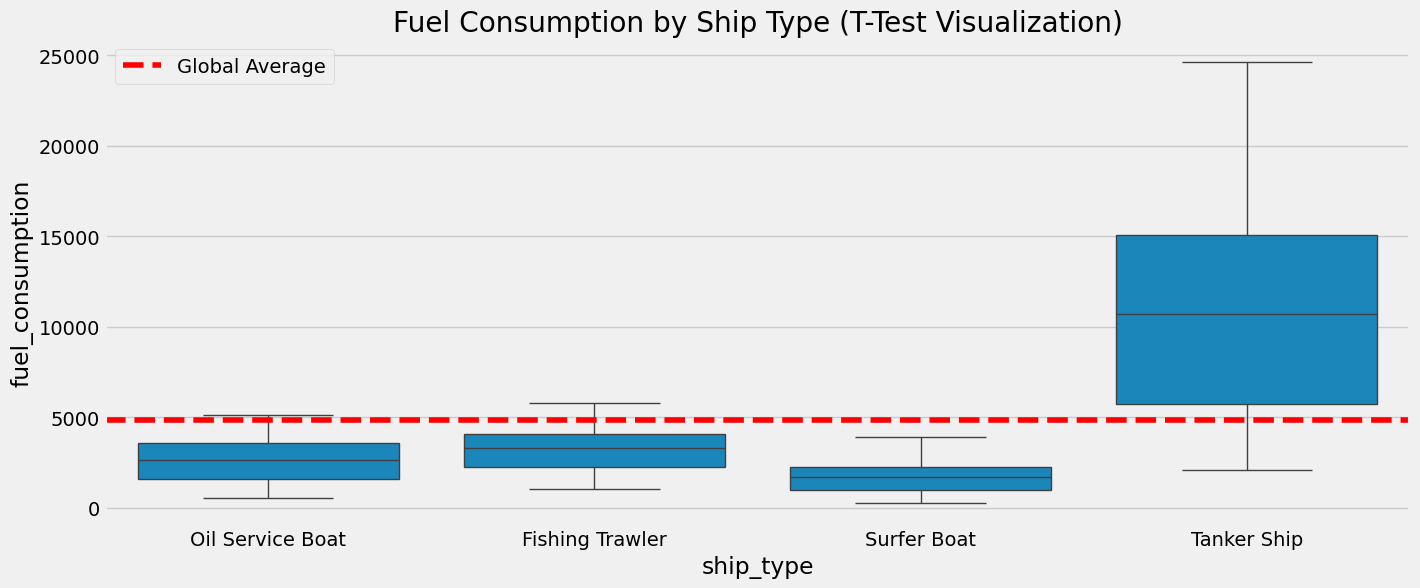

P-value: nan
Result: Fail to Reject Null Hypothesis


In [38]:
# T-Test: Tankers vs Population Mean
tanker_fuel = data[data['ship_type'] == 'Tanker']['fuel_consumption']
t_stat, p_value = stats.ttest_1samp(a=tanker_fuel, popmean=mean_fuel)

# Visualization: Boxplot
sns.boxplot(x='ship_type', y='fuel_consumption', data=data)
plt.axhline(mean_fuel, color='red', linestyle='--', label='Global Average')
plt.title('Fuel Consumption by Ship Type (T-Test Visualization)')
plt.legend()
plt.show()

print(f"P-value: {p_value:.10f}")
if p_value < 0.05:
    print("Result: Reject Null Hypothesis (Tankers are significantly different)")
else:
    print("Result: Fail to Reject Null Hypothesis")

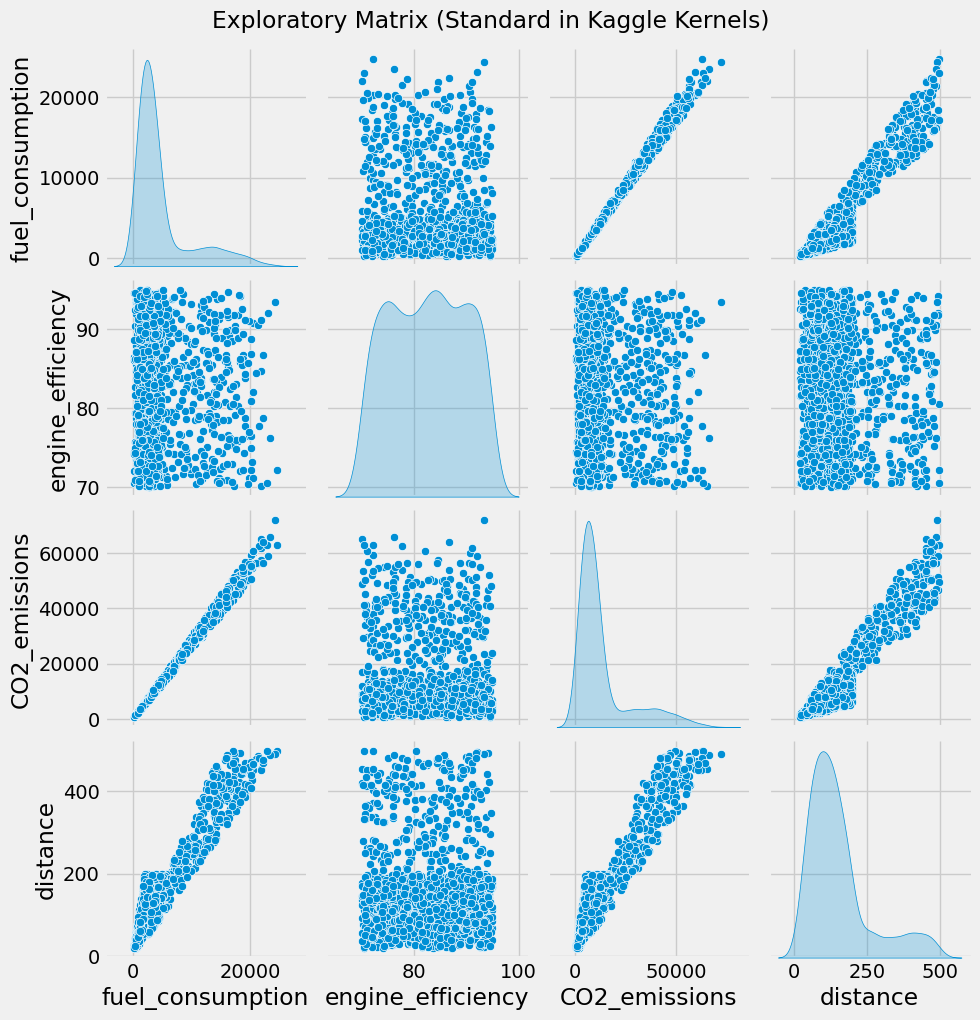

In [ ]:
# This creates a matrix of plots similar to dabl
numeric_cols = ['fuel_consumption', 'engine_efficiency', 'CO2_emissions', 'distance']
sns.pairplot(data[numeric_cols], diag_kind='kde')
plt.suptitle('Exploratory Matrix (Standard in Kaggle Kernels)', y=1.02)
plt.show()

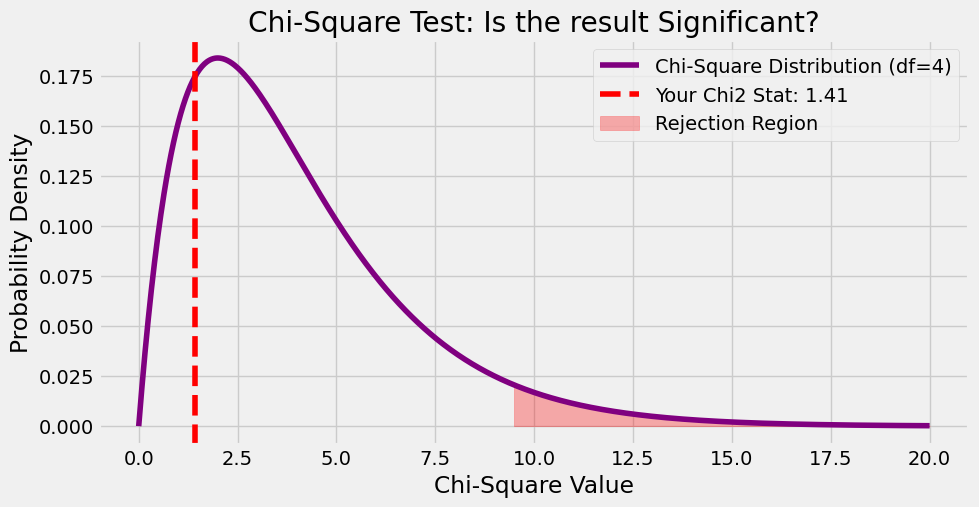

In [41]:
# 1. Generate a Chi-Square distribution based on your Degrees of Freedom (dof)
x = np.linspace(0, 20, 1000)
y = stats.chi2.pdf(x, df=dof)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label=f'Chi-Square Distribution (df={dof})', color='purple')

# 2. Add a vertical line for your calculated Chi-Square Statistic
plt.axvline(chi2, color='red', linestyle='--', label=f'Your Chi2 Stat: {chi2:.2f}')

# 3. Shade the "Significant" area (usually alpha = 0.05)
critical_value = stats.chi2.ppf(q=0.95, df=dof)
plt.fill_between(x, y, where=(x > critical_value), color='red', alpha=0.3, label='Rejection Region')

plt.title("Chi-Square Test: Is the result Significant?")
plt.xlabel("Chi-Square Value")
plt.ylabel("Probability Density")
plt.legend()
plt.show()

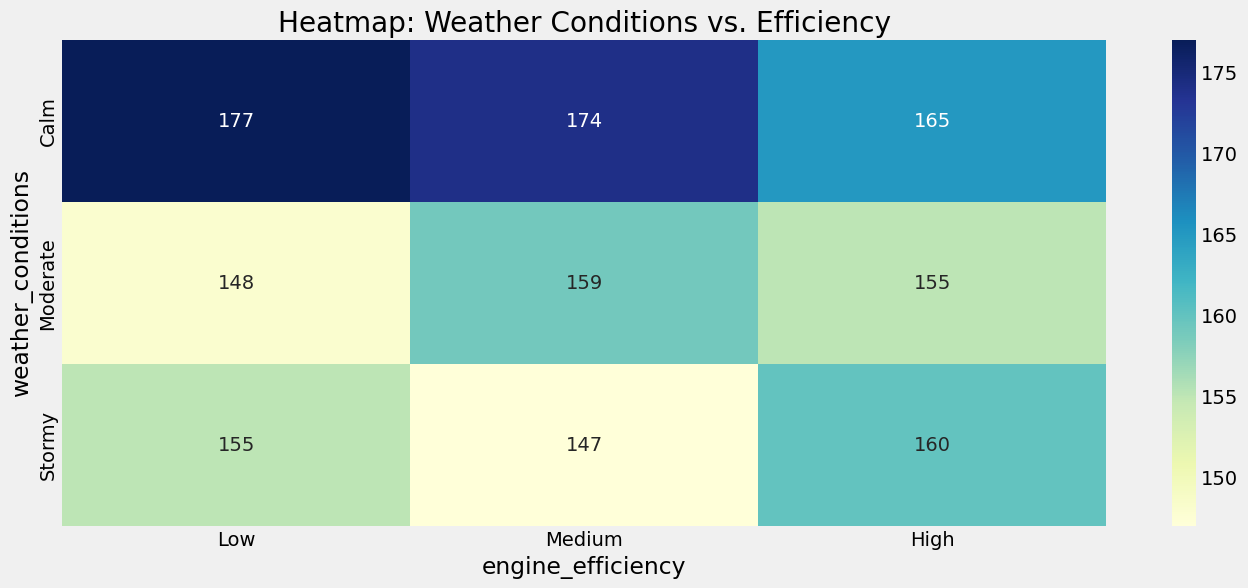

Chi-Square P-value: 0.8416662064596504


In [42]:

# Heatmap Visualization
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Weather Conditions vs. Efficiency')
plt.show()

print(f"Chi-Square P-value: {p_chi}")
if p_chi < 0.05:
    print("Conclusion: Weather and Efficiency are dependent (Weather impacts performance).")

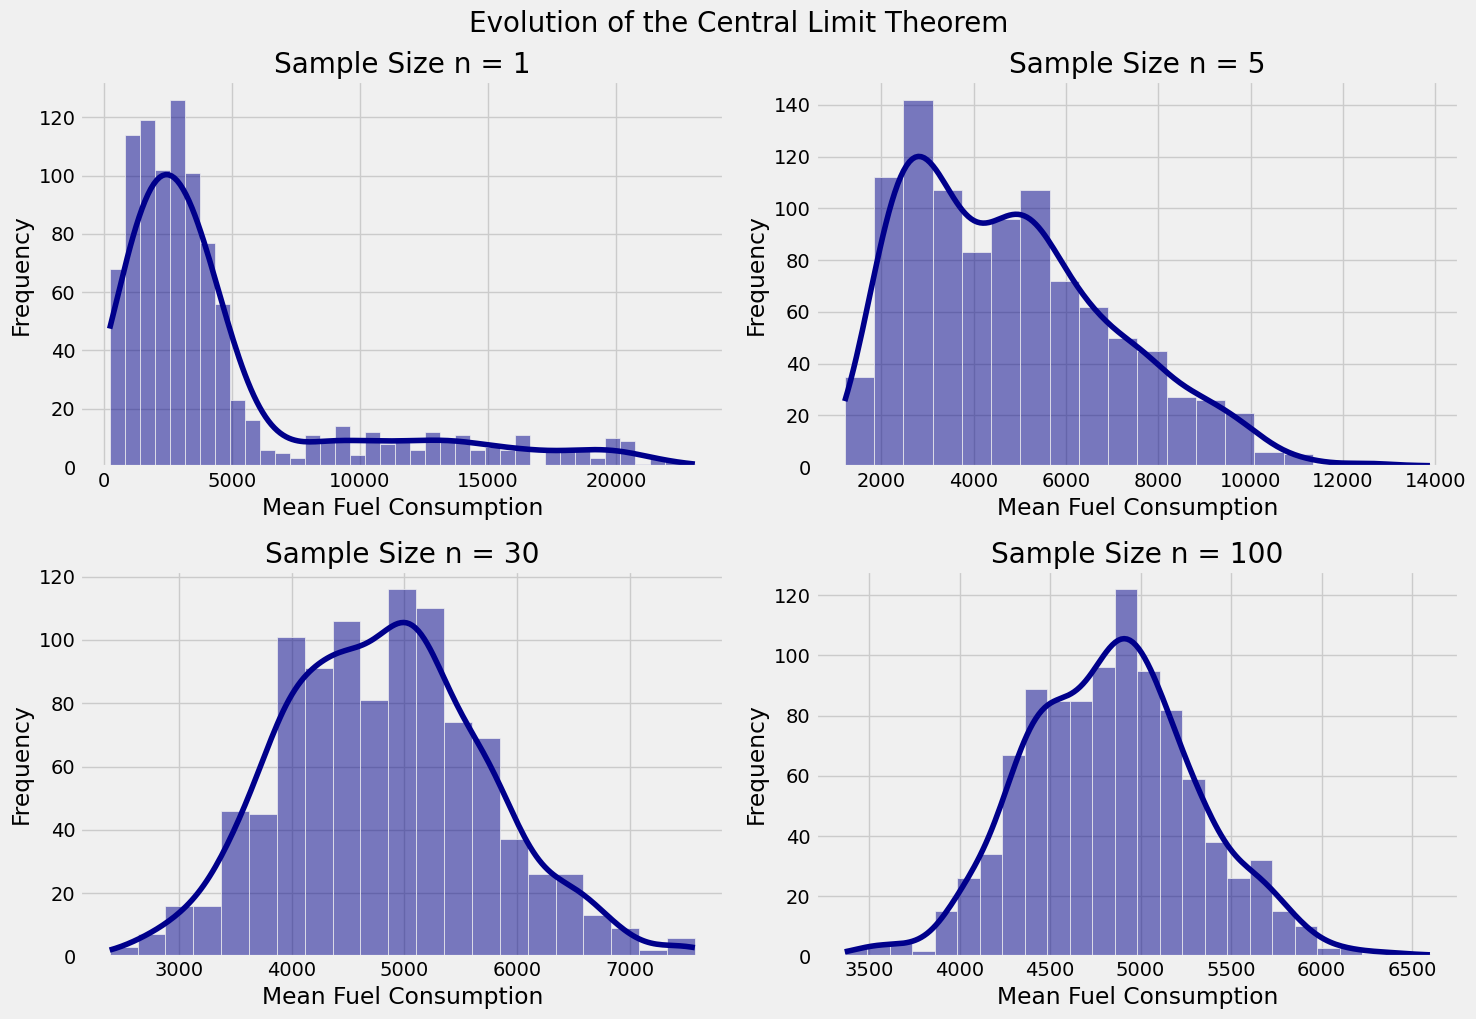

In [43]:
# We will take multiple samples and calculate their means
# To see how the distribution of these means changes with sample size 'n'
sample_sizes = [1, 5, 30, 100]
num_simulations = 1000

plt.figure(figsize=(15, 10))

for i, n in enumerate(sample_sizes):
    # For each n, take 1000 samples of size n and find their means
    sample_means = [data['fuel_consumption'].sample(n).mean() for _ in range(num_simulations)]
    
    # Create a subplot for each sample size
    plt.subplot(2, 2, i + 1)
    sns.histplot(sample_means, kde=True, color='darkblue')
    plt.title(f'Sample Size n = {n}')
    plt.xlabel('Mean Fuel Consumption')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Evolution of the Central Limit Theorem', y=1.02, fontsize=20)
plt.show()